# Skenario 1 — Baseline Model Comparison
**Tujuan:** Membandingkan performa BERT, IndoBERT, DistilBERT, cahyaBERT, cahya-DistilBERT  
**Task:** Klasifikasi Emosi (5 kelas) dan Sentimen (3 kelas)  
**Split:** Stratified 70/10/20 (train/val/test)

---
**Strategi hemat RAM:** Setiap model dilatih satu per satu, hasilnya di-save ke `results_s1.json`, lalu model di-delete dari memori sebelum lanjut ke model berikutnya.

**🏆 Best model:** Model + tokenizer terbaik per task otomatis di-save ke `/kaggle/working/best_model_s1_{task}/`

## 0. Install & Import

In [1]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip("transformers[torch]", "datasets", "accelerate", "scikit-learn",
    "imbalanced-learn", "deep-translator", "nltk", "seaborn", "matplotlib",
    "pandas", "numpy", "torch")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import os, re, json, warnings, random, time, gc
from copy import deepcopy
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


## 1. Load & Preview Dataset

In [3]:
DATA_PATH = "/kaggle/input/datasets/miaikoo/secondary/PRDECT-ID Dataset_clean.csv"

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

print("Shape :", df.shape)
print("Kolom :", df.columns.tolist())
display(df.head(3))

Shape : (5400, 16)
Kolom : ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion', 'Location_grouped', 'review_text', 'review_char_len', 'review_word_len', 'review_tokens']


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion,Location_grouped,review_text,review_char_len,review_word_len,review_tokens
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy,Jakarta Utara,Alhamdulillah berfungsi dengan baik. Packaging...,100,14,"['alhamdulillah', 'berfungsi', 'baik', 'packag..."
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy,Kota Tangerang Selatan,"barang bagus dan respon cepat, harga bersaing ...",61,10,"['barang', 'bagus', 'respon', 'cepat', 'harga'..."
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy,Jakarta Barat,"barang bagus, berfungsi dengan baik, seler ram...",66,9,"['barang', 'bagus', 'berfungsi', 'baik', 'sele..."


## 2. Preprocessing

In [4]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " ", text) 
    text = re.sub(r"[^\w\s]", " ", text)          
    text = re.sub(r"\d+", " ", text)                
    text = re.sub(r"\s+", " ", text).strip()          
    return text

df["text_clean"] = df["Customer Review"].apply(clean_text)

le_sent = LabelEncoder()
le_emot = LabelEncoder()
df["label_sentiment"] = le_sent.fit_transform(df["Sentiment"])
df["label_emotion"]   = le_emot.fit_transform(df["Emotion"])

print("Label Sentimen :", dict(zip(le_sent.classes_, le_sent.transform(le_sent.classes_))))
print("Label Emosi    :", dict(zip(le_emot.classes_, le_emot.transform(le_emot.classes_))))
display(df[["Customer Review","text_clean","Sentiment","label_sentiment","Emotion","label_emotion"]].head(4))

Label Sentimen : {'Negative': np.int64(0), 'Positive': np.int64(1)}
Label Emosi    : {'Anger': np.int64(0), 'Fear': np.int64(1), 'Happy': np.int64(2), 'Love': np.int64(3), 'Sadness': np.int64(4)}


,Customer Review,text_clean,Sentiment,label_sentiment,Emotion,label_emotion
0,Alhamdulillah berfungsi dengan baik. Packaging...,alhamdulillah berfungsi dengan baik packaging ...,Positive,1,Happy,2
1,"barang bagus dan respon cepat, harga bersaing ...",barang bagus dan respon cepat harga bersaing d...,Positive,1,Happy,2
2,"barang bagus, berfungsi dengan baik, seler ram...",barang bagus berfungsi dengan baik seler ramah...,Positive,1,Happy,2
3,bagus sesuai harapan penjual nya juga ramah. t...,bagus sesuai harapan penjual nya juga ramah tr...,Positive,1,Happy,2


## 3. Helper Functions

In [5]:
def make_splits(texts, labels, test_size=0.2, val_size=0.1):
    """Return (train_texts, val_texts, test_texts, train_labels, val_labels, test_labels)"""
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=test_size, random_state=SEED, stratify=labels)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size/(1-test_size), random_state=SEED, stratify=y_train)
    return X_train, X_val, X_test, y_train, y_val, y_test


def build_hf_dataset(texts, labels, tokenizer, max_len=128):
    enc = tokenizer(list(texts), truncation=True, padding="max_length",
                    max_length=max_len, return_tensors="pt")
    return HFDataset.from_dict({
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels":         list(labels),
    })


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }


def train_and_evaluate(model_name, train_ds, val_ds, test_texts, test_labels,
                       tokenizer, num_labels, label_names,
                       output_dir="./tmp_model",
                       num_epochs=3, batch_size=16, lr=2e-5,
                       weight_decay=0.01, dropout=None,
                       warmup_ratio=0.1, max_len=128):
    """Fine-tune a transformer and return (trainer, metrics_dict, classification_report_str)"""

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, ignore_mismatched_sizes=True)

    if dropout is not None and hasattr(model.config, "hidden_dropout_prob"):
        model.config.hidden_dropout_prob = dropout
        model.config.attention_probs_dropout_prob = dropout

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        save_only_model=True,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        fp16=(DEVICE == "cuda"),
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer, max_len)
    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    metrics = {
        "accuracy":    round(accuracy_score(test_labels, preds), 4),
        "f1_macro":    round(f1_score(test_labels, preds, average="macro"), 4),
        "f1_weighted": round(f1_score(test_labels, preds, average="weighted"), 4),
        "train_time_s": round(elapsed, 1),
    }

    report = classification_report(test_labels, preds, target_names=label_names)

    return trainer, metrics, report, preds


def show_results(metrics, report, title=""):
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        print(f"  {k:20s}: {v}")
    print()
    print(report)


def free_memory():
    """Bebaskan GPU/CPU memory setelah tiap model."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def save_best_model(trainer, tokenizer, task_name, model_alias, model_name, metrics, label_names):
    """Simpan model + tokenizer + metadata ke folder best_model_s1_{task}."""
    best_dir = f"/kaggle/working/best_model_s1_{task_name}"
    os.makedirs(best_dir, exist_ok=True)
    trainer.save_model(best_dir)
    tokenizer.save_pretrained(best_dir)
    # Simpan metadata
    meta = {
        "skenario": "1",
        "task": task_name,
        "model_alias": model_alias,
        "model_name": model_name,
        "label_names": list(label_names),
        "metrics": metrics,
    }
    with open(f"{best_dir}/best_model_info.json", "w") as f:
        json.dump(meta, f, indent=2)
    print(f"  🏆 [BEST MODEL] {model_alias} (f1_macro={metrics['f1_macro']:.4f}) → saved to {best_dir}")

---
# SKENARIO 1 — Baseline Model Comparison

Setiap model dilatih satu per satu → hasilnya di-save ke JSON → **best model per task di-save** → memory dibebaskan.

In [6]:
BASELINE_MODELS = {
    "BERT":      "bert-base-multilingual-cased",
    "IndoBERT":  "indobenchmark/indobert-base-p1",
    "DistilBERT": "distilbert-base-multilingual-cased",
    "cahyaBERT": "cahya/bert-base-indonesian-522M",
    "cahya-DistilBERT": "cahya/distilbert-base-indonesian",
}

TASKS = {
    "Emotion":   ("text_clean", "label_emotion",   le_emot.classes_),
    "Sentiment": ("text_clean", "label_sentiment", le_sent.classes_),
}

RESULTS_FILE = "/kaggle/working/results_s1.json"

# Load hasil yang sudah ada (kalau ada, untuk resume)
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        BASELINE_RESULTS = json.load(f)
    print(f"Resume dari hasil yang sudah ada: {list(BASELINE_RESULTS.keys())}")
else:
    BASELINE_RESULTS = {}
    print("Mulai dari awal.")

# Tracker best model per task: {task_name: {"f1_macro": float, "model_alias": str}}
BEST_MODEL_TRACKER = {}

Mulai dari awal.


In [7]:
for task_name, (text_col, label_col, label_names) in TASKS.items():
    texts  = df[text_col].values
    labels = df[label_col].values
    num_labels = len(label_names)

    train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = make_splits(texts, labels)
    print(f"\n[{task_name}] Train={len(train_texts)}, Val={len(val_texts)}, Test={len(test_texts)}")

    for model_alias, model_name in BASELINE_MODELS.items():
        # Skip jika sudah dilatih sebelumnya (resume) — tapi update tracker
        if task_name in BASELINE_RESULTS and model_alias in BASELINE_RESULTS[task_name]:
            print(f"  [SKIP] {model_alias} ({task_name}) sudah ada.")
            # Tetap update tracker dari hasil lama
            existing_f1 = BASELINE_RESULTS[task_name][model_alias]["metrics"]["f1_macro"]
            if task_name not in BEST_MODEL_TRACKER or existing_f1 > BEST_MODEL_TRACKER[task_name]["f1_macro"]:
                BEST_MODEL_TRACKER[task_name] = {"f1_macro": existing_f1, "model_alias": model_alias, "model_name": model_name}
            continue

        print(f"\n>>> Training {model_alias} ({model_name}) — Task: {task_name}")

        try:
            tokenizer = AutoTokenizer.from_pretrained(model_name)

            train_ds = build_hf_dataset(train_texts, train_labels, tokenizer)
            val_ds   = build_hf_dataset(val_texts,   val_labels,   tokenizer)

            output_dir = f"/kaggle/working/s1_{task_name}_{model_alias}"

            trainer, metrics, report, preds = train_and_evaluate(
                model_name, train_ds, val_ds, test_texts, test_labels,
                tokenizer, num_labels, label_names,
                output_dir=output_dir,
            )

            show_results(metrics, report, title=f"{model_alias} | {task_name}")

            # Simpan hasil ke dict
            if task_name not in BASELINE_RESULTS:
                BASELINE_RESULTS[task_name] = {}
            BASELINE_RESULTS[task_name][model_alias] = {
                "metrics": metrics,
                "report":  report,
            }

            # ── Cek & simpan best model ──────────────────────────────────────
            current_f1 = metrics["f1_macro"]
            if task_name not in BEST_MODEL_TRACKER or current_f1 > BEST_MODEL_TRACKER[task_name]["f1_macro"]:
                BEST_MODEL_TRACKER[task_name] = {
                    "f1_macro": current_f1,
                    "model_alias": model_alias,
                    "model_name": model_name,
                }
                save_best_model(trainer, tokenizer, task_name, model_alias, model_name, metrics, label_names)
            else:
                print(f"  (bukan best: f1_macro={current_f1:.4f} < best={BEST_MODEL_TRACKER[task_name]['f1_macro']:.4f})")

            # Simpan ke JSON (incremental save)
            with open(RESULTS_FILE, "w") as f:
                json.dump(BASELINE_RESULTS, f, indent=2)
            print(f"  [SAVED] Hasil disimpan ke {RESULTS_FILE}")

            # Bebaskan memori
            del trainer, tokenizer, train_ds, val_ds
            free_memory()

        except Exception as e:
            print(f"  [ERROR] {model_alias} ({task_name}): {e}")
            free_memory()

print("\n✅ Skenario 1 selesai!")
print("\n🏆 Best Models per Task:")
for task, info in BEST_MODEL_TRACKER.items():
    print(f"  {task}: {info['model_alias']} (f1_macro={info['f1_macro']:.4f}) → /kaggle/working/best_model_s1_{task}/")


[Emotion] Train=3780, Val=540, Test=1080

>>> Training BERT (bert-base-multilingual-cased) — Task: Emotion


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  cahya-DistilBERT | Sentiment
  accuracy            : 0.9694
  f1_macro            : 0.9694
  f1_weighted         : 0.9694
  train_time_s        : 92.4

              precision    recall  f1-score   support

    Negative       0.96      0.98      0.97       564
    Positive       0.98      0.96      0.97       516

    accuracy                           0.97      1080
   macro avg       0.97      0.97      0.97      1080
weighted avg       0.97      0.97      0.97      1080

  (bukan best: f1_macro=0.9694 < best=0.9824)
  [SAVED] Hasil disimpan ke /kaggle/working/results_s1.json

✅ Skenario 1 selesai!

🏆 Best Models per Task:
  Emotion: IndoBERT (f1_macro=0.6617) → /kaggle/working/best_model_s1_Emotion/
  Sentiment: IndoBERT (f1_macro=0.9824) → /kaggle/working/best_model_s1_Sentiment/


In [8]:
# Tabel perbandingan baseline
rows = []
for task_name, models in BASELINE_RESULTS.items():
    for model_alias, result in models.items():
        row = {"Task": task_name, "Model": model_alias}
        row.update(result["metrics"])
        rows.append(row)

df_results_s1 = pd.DataFrame(rows)
print("\nTabel Perbandingan Baseline — Skenario 1")
display(df_results_s1.sort_values(["Task","f1_macro"], ascending=[True,False])
                       .reset_index(drop=True))


Tabel Perbandingan Baseline — Skenario 1


,Task,Model,accuracy,f1_macro,f1_weighted,train_time_s
0,Emotion,IndoBERT,0.6917,0.6617,0.6940,170.6
1,Emotion,cahya-DistilBERT,0.6648,0.6219,0.6604,92.8
2,Emotion,cahyaBERT,0.6472,0.6187,0.6494,166.1
3,Emotion,BERT,0.6509,0.6040,0.6425,192.2
4,Emotion,DistilBERT,0.6278,0.5766,0.6176,113.9
5,Sentiment,IndoBERT,0.9824,0.9824,0.9824,170.3
6,Sentiment,cahya-DistilBERT,0.9694,0.9694,0.9694,92.4
7,Sentiment,cahyaBERT,0.9667,0.9666,0.9667,164.9
8,Sentiment,DistilBERT,0.9509,0.9508,0.9509,113.4
9,Sentiment,BERT,0.9500,0.9499,0.9500,192.4


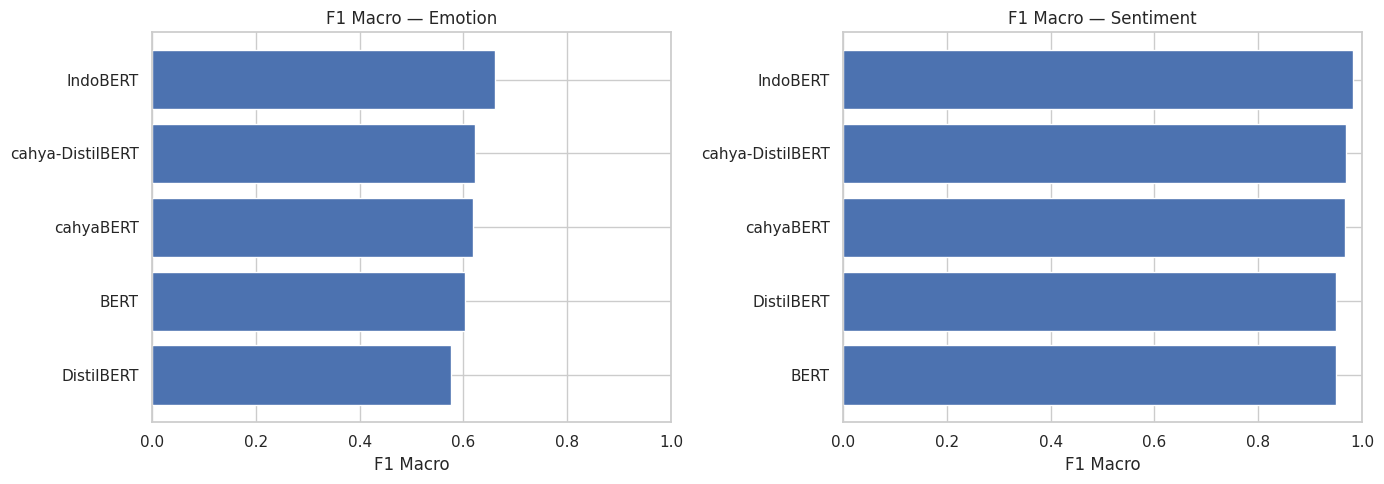

Plot disimpan ke /kaggle/working/s1_comparison.png


In [9]:
# Visualisasi
if not df_results_s1.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, task in zip(axes, ["Emotion", "Sentiment"]):
        sub = df_results_s1[df_results_s1["Task"] == task].sort_values("f1_macro")
        ax.barh(sub["Model"], sub["f1_macro"])
        ax.set_title(f"F1 Macro — {task}")
        ax.set_xlabel("F1 Macro")
        ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.savefig("/kaggle/working/s1_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot disimpan ke /kaggle/working/s1_comparison.png")

In [10]:
# ── Contoh cara load best model yang sudah disimpan ──────────────────────
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# import json
#
# task = "Emotion"  # atau "Sentiment"
# best_dir = f"/kaggle/working/best_model_s1_{task}"
#
# with open(f"{best_dir}/best_model_info.json") as f:
#     info = json.load(f)
# print(info)
#
# tokenizer = AutoTokenizer.from_pretrained(best_dir)
# model = AutoModelForSequenceClassification.from_pretrained(best_dir)
# print("Uncomment kode di atas untuk load best model.")

In [11]:
import shutil
shutil.make_archive('/kaggle/working/model_final', 'zip', '/kaggle/working/best_model_s1_Sentiment')

'/kaggle/working/model_final.zip'


Membuat Word Cloud berdasarkan hasil PREDIKSI Best Model (Tanpa Stopwords)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

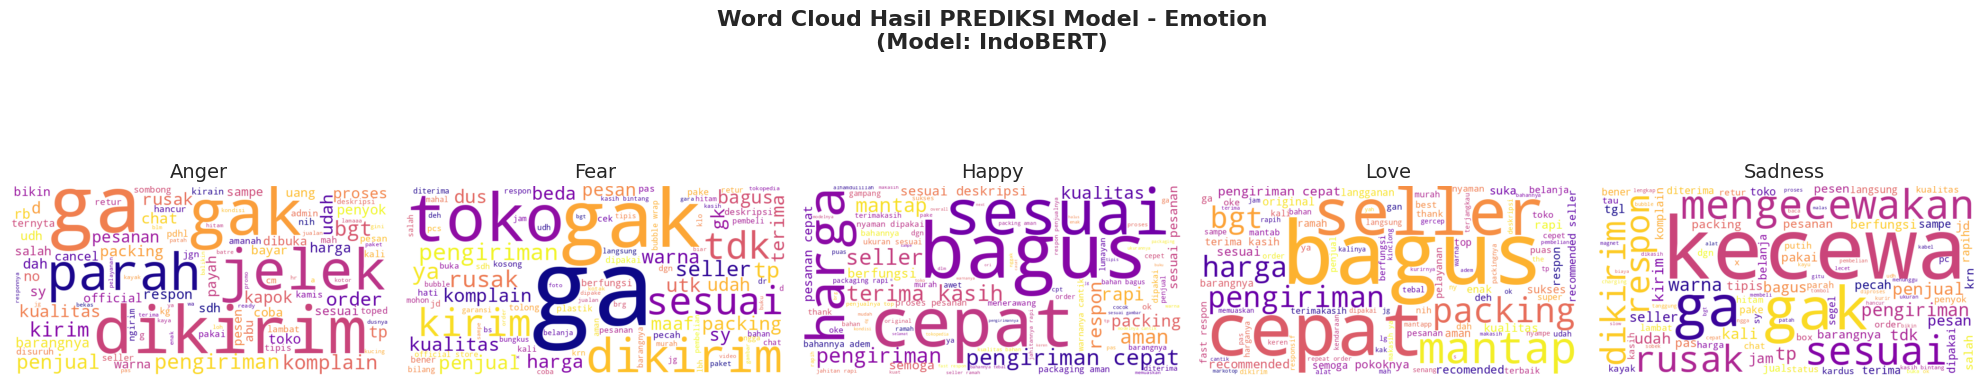

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

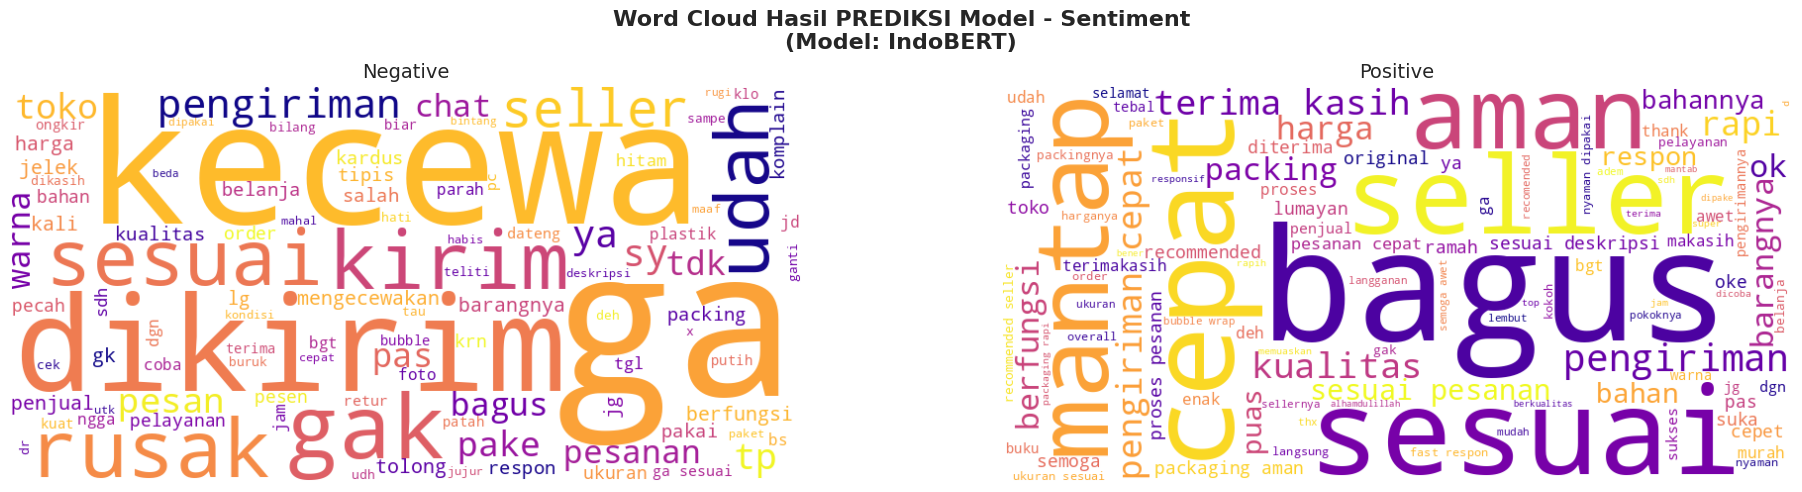

In [12]:
# ==========================================
# 1. WORD CLOUD HASIL PREDIKSI MODEL TERBAIK (Tanpa Stopwords)
# ==========================================
pip("wordcloud", "nltk")
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

# Download kamus stopwords dari NLTK
nltk.download('stopwords', quiet=True)
indo_stopwords = set(stopwords.words('indonesian'))

# Tambahkan custom stopwords (kata slang/umum di review yang ingin diabaikan)
custom_stopwords = {
    "yg", "nya", "di", "ke", "dari", "dan", "ini", "itu", "untuk", "dengan", 
    "yang", "ada", "juga", "sudah", "buat", "karena", "kalo", "aku", "saya", 
    "aja", "sama", "barang", "produk", "beli", "banget", "sih", "kok"
}
indo_stopwords = indo_stopwords.union(custom_stopwords)

print("\nMembuat Word Cloud berdasarkan hasil PREDIKSI Best Model (Tanpa Stopwords)...")

for task_name, (text_col, label_col, label_names) in TASKS.items():
    best_dir = f"/kaggle/working/best_model_s1_{task_name}"
    
    if not os.path.exists(best_dir):
        print(f"Directory {best_dir} tidak ditemukan. Lewati task {task_name}.")
        continue

    # 1. Load data test kembali
    texts = df[text_col].values
    labels = df[label_col].values
    _, _, test_texts, _, _, test_labels = make_splits(texts, labels)
    
    # 2. Load Best Model & Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)
    
    # 3. Prediksi pada data Test
    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer)
    trainer = Trainer(model=model)
    
    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)
    
    # 4. Buat DataFrame sementara untuk hasil prediksi
    df_pred = pd.DataFrame({
        "text": test_texts,
        "pred_label": [label_names[p] for p in preds]
    })
    
    # 5. Generate Word Cloud per kelas hasil prediksi
    fig, axes = plt.subplots(1, len(label_names), figsize=(20, 5))
    fig.suptitle(f"Word Cloud Hasil PREDIKSI Model - {task_name}\n(Model: {BEST_MODEL_TRACKER[task_name]['model_alias']})", 
                 fontsize=16, fontweight='bold')
    
    # Jika hanya ada 1 row/kolom di subplot, pastikan 'axes' bisa di-iterasi
    if len(label_names) == 1:
        axes = [axes]
        
    for ax, cls in zip(axes, label_names):
        # Ambil teks yang DIPREDIKSI sebagai kelas 'cls' oleh model
        text_data = " ".join(df_pred[df_pred["pred_label"] == cls]["text"].tolist())
        
        # Cek jika model sama sekali tidak memprediksi kelas ini
        if text_data.strip() == "":
            ax.set_title(f"{cls}\n(Tidak diprediksi)", fontsize=14, color='red')
            ax.axis("off")
            continue
            
        # PENTING: Masukkan parameter stopwords ke dalam WordCloud
        wc = WordCloud(width=800, height=400, background_color='white', 
                       colormap='plasma', max_words=100, 
                       stopwords=indo_stopwords).generate(text_data)
        
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(cls, fontsize=14)
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()
    
    # Bersihkan memori
    del model, tokenizer, trainer, test_ds, df_pred
    free_memory()


Memproses Prediksi untuk Crosstab Semua Model...
Catatan: Ini akan me-load checkpoint model satu per satu, harap tunggu...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

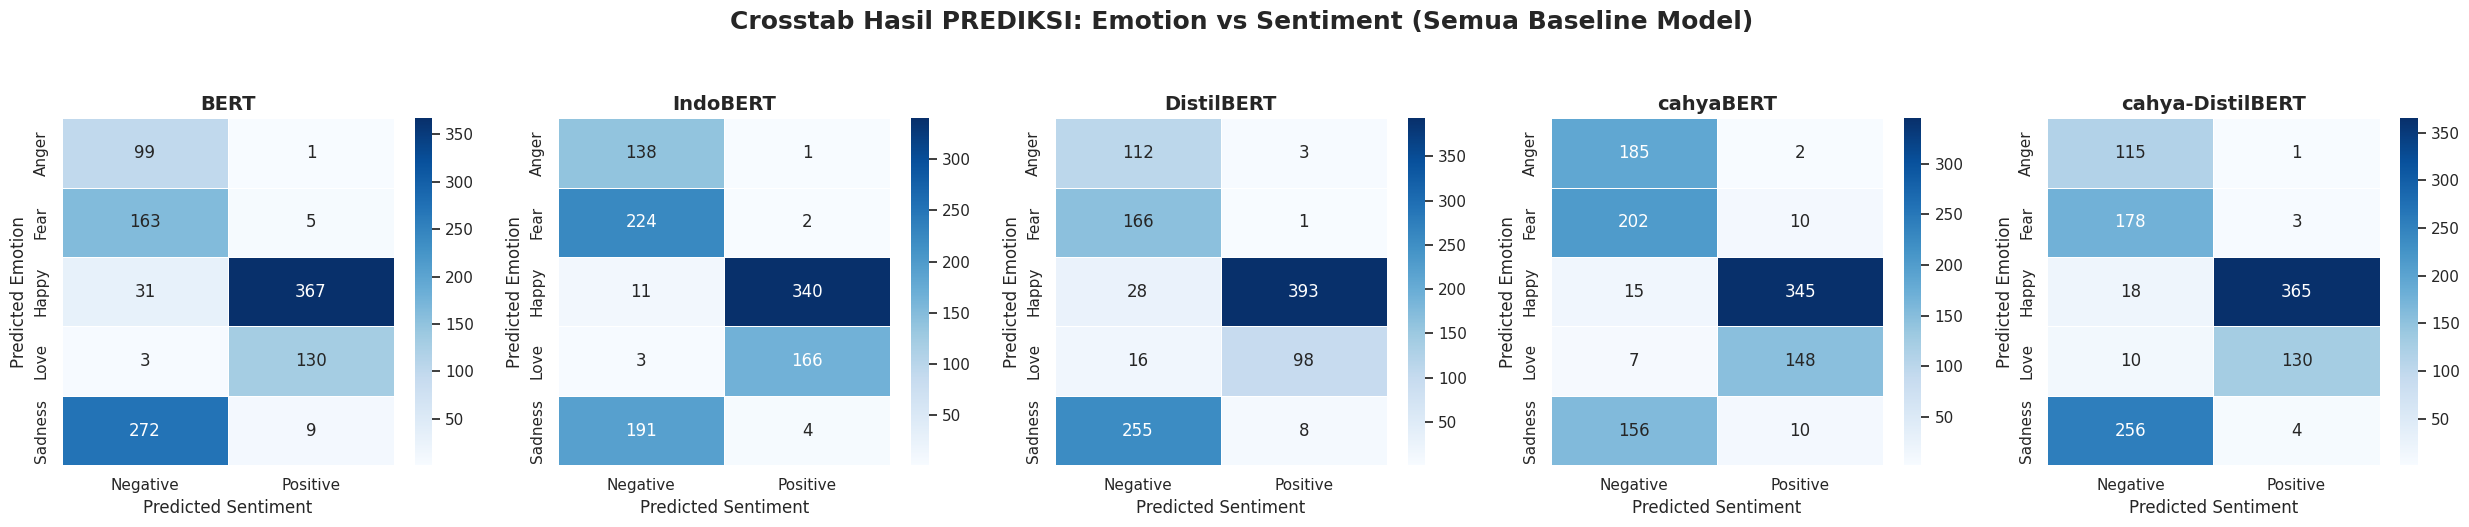

In [13]:
# ==========================================
# 4. CROSSTAB PREDIKSI UNTUK SEMUA MODEL (REVISI)
# ==========================================
import glob
import os

print("\nMemproses Prediksi untuk Crosstab Semua Model...")
print("Catatan: Ini akan me-load checkpoint model satu per satu, harap tunggu...")

# Siapkan 5 plot berjajar
fig, axes = plt.subplots(1, len(BASELINE_MODELS), figsize=(25, 5))
fig.suptitle("Crosstab Hasil PREDIKSI: Emotion vs Sentiment (Semua Baseline Model)", 
             fontsize=18, fontweight='bold', y=1.05)

# 1. Ambil data teks testing
texts = df["text_clean"].values
labels_dummy = df["label_emotion"].values 
_, _, test_texts, _, _, _ = make_splits(texts, labels_dummy)

for idx, (model_alias, model_name) in enumerate(BASELINE_MODELS.items()):
    preds_dict = {}
    
    for task_name, (_, _, label_names) in TASKS.items():
        base_dir = f"/kaggle/working/s1_{task_name}_{model_alias}"
        ckpts = glob.glob(f"{base_dir}/checkpoint-*")
        
        if not ckpts:
            print(f"  ⚠️ Checkpoint {model_alias} ({task_name}) tidak ditemukan. Lewati...")
            preds_dict[task_name] = ["Unknown"] * len(test_texts)
            continue
            
        # Ambil checkpoint terakhir
        latest_ckpt = sorted(ckpts, key=lambda x: int(x.split('-')[-1]))[-1]
        
        # ─── FIX UTAMA ADA DI SINI ───────────────────────────────────────
        # Load Tokenizer langsung dari base model (model_name), bukan dari checkpoint.
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        # Model tetap di-load dari checkpoint karena butuh bobot hasil training.
        model = AutoModelForSequenceClassification.from_pretrained(latest_ckpt).to(DEVICE)
        # ─────────────────────────────────────────────────────────────────
        
        test_ds = build_hf_dataset(test_texts, [0]*len(test_texts), tokenizer)
        trainer = Trainer(model=model)
        
        preds_raw = trainer.predict(test_ds)
        preds_logits = preds_raw.predictions[0] if isinstance(preds_raw.predictions, tuple) else preds_raw.predictions
        preds_class = np.argmax(preds_logits, axis=-1)
        
        # Simpan hasil tebakan bentuk string
        preds_dict[task_name] = [label_names[p] for p in preds_class]
        
        # Bersihkan memori
        del model, tokenizer, trainer, test_ds
        free_memory()
        
    # 2. Bikin Dataframe khusus hasil tebakan model ini
    df_pred = pd.DataFrame({
        'Pred_Emotion': preds_dict.get('Emotion', ["Unknown"] * len(test_texts)),
        'Pred_Sentiment': preds_dict.get('Sentiment', ["Unknown"] * len(test_texts))
    })
    
    # 3. Hitung Crosstab
    cross_tab = pd.crosstab(df_pred['Pred_Emotion'], df_pred['Pred_Sentiment'])
    
    # 4. Gambar Heatmap
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', linewidths=.5, ax=axes[idx])
    axes[idx].set_title(f"{model_alias}", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Predicted Sentiment")
    axes[idx].set_ylabel("Predicted Emotion")

plt.tight_layout()
plt.show()


Memuat model terbaik dan membuat Confusion Matrix...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

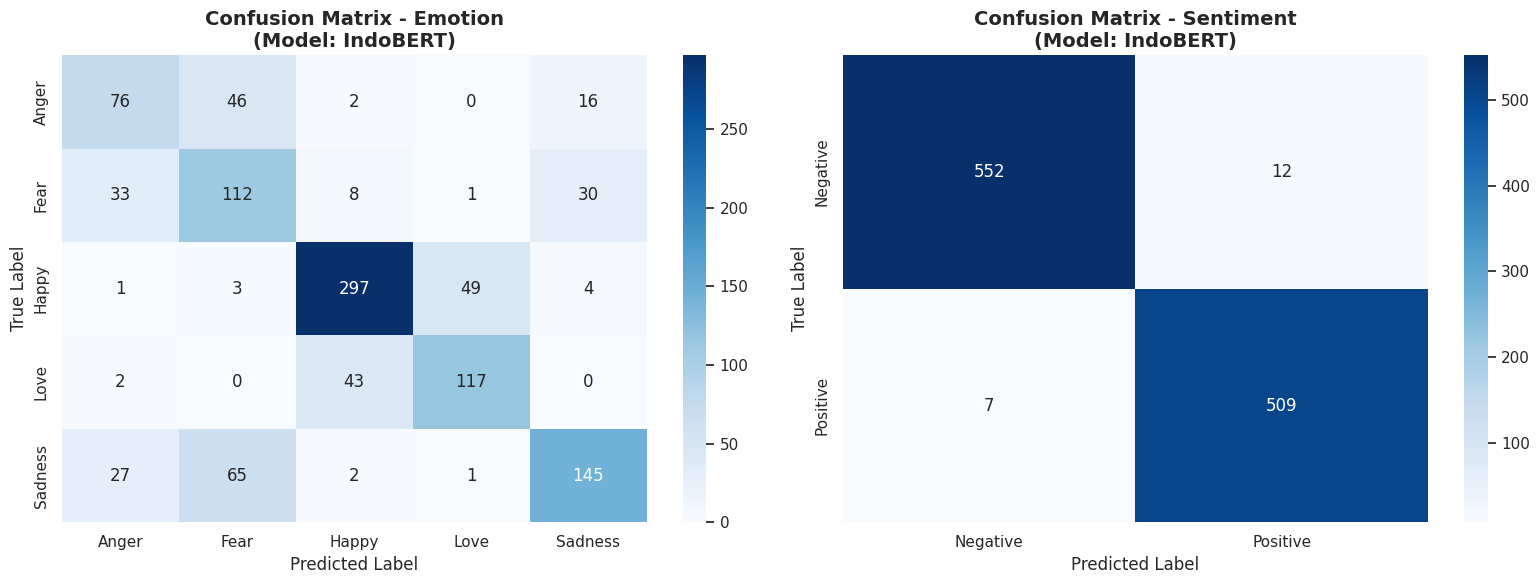

In [14]:
# ==========================================
# 3. CONFUSION MATRIX (Best Models)
# ==========================================
print("\nMemuat model terbaik dan membuat Confusion Matrix...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (task_name, (text_col, label_col, label_names)) in enumerate(TASKS.items()):
    best_dir = f"/kaggle/working/best_model_s1_{task_name}"
    
    if not os.path.exists(best_dir):
        print(f"Directory {best_dir} tidak ditemukan. Lewati task {task_name}.")
        continue

    # 1. Load data test kembali (memastikan split konsisten dengan seed yang sama)
    texts = df[text_col].values
    labels = df[label_col].values
    _, _, test_texts, _, _, test_labels = make_splits(texts, labels)
    
    # 2. Load Best Model & Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)
    
    # 3. Prediksi pada data Test
    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer)
    trainer = Trainer(model=model)
    
    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)
    
    # 4. Plot Confusion Matrix
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names, yticklabels=label_names, ax=axes[idx])
    
    # Format Plot
    axes[idx].set_title(f"Confusion Matrix - {task_name}\n(Model: {BEST_MODEL_TRACKER[task_name]['model_alias']})", 
                        fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")
    
    # Bersihkan memori model setelah inference
    del model, tokenizer, trainer, test_ds
    free_memory()

plt.tight_layout()
plt.show()